# Optional Supplement 01: Train a Tiny ViT to Classify Handwritten Digits

This notebook builds a small Vision Transformer (`ViT`) from scratch and trains it on a balanced subset of MNIST. The task is binary image classification: handwritten **3 or 8**.

The goal is to see the implementation—not to build a production classifier. This model cannot authenticate an image, establish provenance, or support a forensic conclusion by itself.

## Step 1: Setup

The first run downloads MNIST (about 12 MB) into this supplement's `data/` folder. It does not require Ollama, an API key, or `.env`.

If an import fails, install the course dependencies from the repository root:

```bash
pip install -r requirements.txt
```

In [1]:
import random
import time
from pathlib import Path

try:
    import matplotlib.pyplot as plt
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import datasets, transforms
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'PyTorch, Torchvision, and Matplotlib are required. Run `pip install -r requirements.txt` from the repository root.'
    ) from exc

LAB_NAME = 'sub_01_vit_foundations'
lab_dir = Path.cwd().resolve()
if lab_dir.name != LAB_NAME:
    raise FileNotFoundError(f'Open this notebook from the {LAB_NAME} folder.')

data_dir = lab_dir / 'data'
data_dir.mkdir(exist_ok=True)

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Torch version:', torch.__version__)
print('Torchvision is available.')
print('Training device:', device)

Torch version: 2.14.0+cu130
Torchvision is available.
Training device: cpu


## Step 2: Download and Select a Small Dataset

MNIST contains `28 × 28` grayscale images of handwritten digits. Its original training and test splits are separate. We keep that separation, select only digits `3` and `8`, and create balanced subsets with a fixed seed.

The pixel values are normalized from `[0, 1]` to approximately `[-1, 1]` for training.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

full_train = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
full_test = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

ORIGINAL_TO_BINARY = {3: 0, 8: 1}
CLASS_NAMES = ['3', '8']

def balanced_indices(targets, per_class, seed):
    """Return a reproducible, balanced list of digit 3 and digit 8 indices."""
    rng = random.Random(seed)
    selected = []
    for original_label in ORIGINAL_TO_BINARY:
        candidates = [i for i, label in enumerate(targets) if label == original_label]
        rng.shuffle(candidates)
        selected.extend(candidates[:per_class])
    rng.shuffle(selected)
    return selected

class BinaryDigitDataset(Dataset):
    """Expose selected MNIST images with labels 0=digit 3 and 1=digit 8."""
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        image, original_label = self.base_dataset[self.indices[position]]
        return image, ORIGINAL_TO_BINARY[original_label]

train_indices = balanced_indices(full_train.targets, per_class=1000, seed=SEED)
test_indices = balanced_indices(full_test.targets, per_class=200, seed=SEED + 1)
train_dataset = BinaryDigitDataset(full_train, train_indices)
test_dataset = BinaryDigitDataset(full_test, test_indices)

train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, generator=train_generator)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

train_counts = [sum(int(full_train.targets[i]) == label for i in train_indices) for label in (3, 8)]
test_counts = [sum(int(full_test.targets[i]) == label for i in test_indices) for label in (3, 8)]
print(f'Training examples: {len(train_dataset)} (digit 3={train_counts[0]}, digit 8={train_counts[1]})')
print(f'Test examples:     {len(test_dataset)} (digit 3={test_counts[0]}, digit 8={test_counts[1]})')
assert train_counts == [1000, 1000] and test_counts == [200, 200]

Training examples: 2000 (digit 3=1000, digit 8=1000)
Test examples:     400 (digit 3=200, digit 8=200)


The numeric indices in the two splits may overlap, but they address two different source datasets (`full_train` and `full_test`). No test image is copied into the training split. Now display a few normalized images after converting them back to `[0, 1]` for viewing.

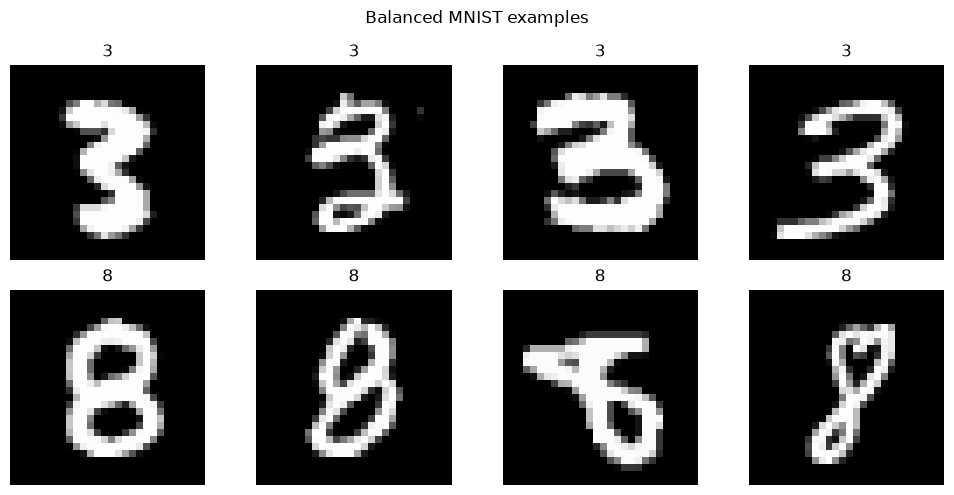

In [3]:
def image_for_display(image):
    return ((image * 0.5) + 0.5).clamp(0, 1).squeeze(0)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
examples_by_class = {0: [], 1: []}
for image, label in train_dataset:
    if len(examples_by_class[label]) < 4:
        examples_by_class[label].append(image)
    if all(len(items) == 4 for items in examples_by_class.values()):
        break

for row, label in enumerate((0, 1)):
    for column, image in enumerate(examples_by_class[label]):
        axes[row, column].imshow(image_for_display(image), cmap='gray', vmin=0, vmax=1)
        axes[row, column].set_title(CLASS_NAMES[label])
        axes[row, column].axis('off')
plt.suptitle('Balanced MNIST examples')
plt.tight_layout()
plt.show()

## Step 3: Turn an Image into Patch Vectors

A `28 × 28` image divided into `4 × 4` patches has 7 patches across and 7 down: `7 × 7 = 49` patches. Each grayscale patch contains `1 × 4 × 4 = 16` pixel values.

The next cell rearranges one image into those 49 patches. This is only a visualization; the model performs the same rearrangement with `nn.Unfold`.

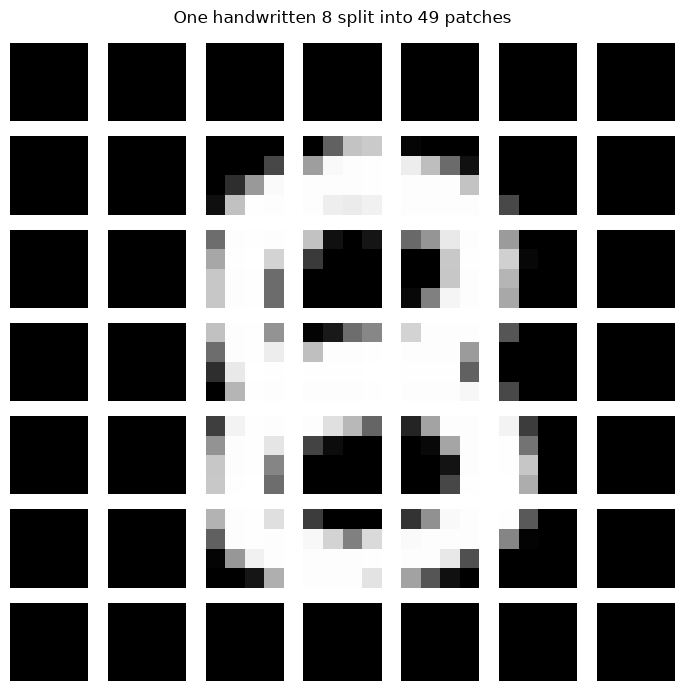

Original image shape: (1, 28, 28)
Patch grid: (7, 7) with 4 × 4 grayscale values per patch


In [4]:
PATCH_SIZE = 4
sample_image, sample_label = train_dataset[0]
display_image = image_for_display(sample_image)
patches = display_image.unfold(0, PATCH_SIZE, PATCH_SIZE).unfold(1, PATCH_SIZE, PATCH_SIZE)

fig, axes = plt.subplots(7, 7, figsize=(7, 7))
for row in range(7):
    for column in range(7):
        patch = patches[row, column]
        axes[row, column].imshow(patch, cmap='gray', vmin=0, vmax=1)
        axes[row, column].axis('off')
plt.suptitle(f'One handwritten {CLASS_NAMES[sample_label]} split into 49 patches')
plt.tight_layout()
plt.show()
print('Original image shape:', tuple(sample_image.shape))
print('Patch grid:', tuple(patches.shape[:2]), 'with 4 × 4 grayscale values per patch')

## Step 4: Implement a Tiny Vision Transformer

The implementation keeps the important ViT stages visible:

1. `nn.Unfold` extracts flattened patch vectors.
2. A linear layer projects each 16-value patch into a 64-value embedding.
3. The model prepends a learned `[CLS]` token and adds learned position embeddings.
4. Two encoder blocks process all 50 tokens. There is no causal mask.
5. The classification head maps the final `[CLS]` representation to digit `3` and digit `8` logits.

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=28, patch_size=4, channels=1, embedding_size=64):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError('image_size must be divisible by patch_size')
        self.number_of_patches = (image_size // patch_size) ** 2
        self.patch_dimension = channels * patch_size * patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.projection = nn.Linear(self.patch_dimension, embedding_size)

    def patch_vectors(self, images):
        # nn.Unfold returns (batch, patch values, patches); transpose puts patches second.
        return self.unfold(images).transpose(1, 2)

    def forward(self, images):
        return self.projection(self.patch_vectors(images))


class TinyVisionTransformer(nn.Module):
    def __init__(self, image_size=28, patch_size=4, embedding_size=64, heads=4, layers=2, classes=2):
        super().__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, 1, embedding_size)
        token_count = self.patch_embedding.number_of_patches + 1
        self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_size))
        self.position_embedding = nn.Parameter(torch.zeros(1, token_count, embedding_size))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_size,
            nhead=heads,
            dim_feedforward=embedding_size * 2,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers, enable_nested_tensor=False)
        self.final_norm = nn.LayerNorm(embedding_size)
        self.classification_head = nn.Linear(embedding_size, classes)
        nn.init.normal_(self.class_token, std=0.02)
        nn.init.normal_(self.position_embedding, std=0.02)

    def tokens_before_encoder(self, images):
        patch_embeddings = self.patch_embedding(images)
        class_tokens = self.class_token.expand(images.shape[0], -1, -1)
        tokens = torch.cat((class_tokens, patch_embeddings), dim=1)
        return tokens + self.position_embedding

    def forward(self, images):
        tokens = self.tokens_before_encoder(images)
        encoded_tokens = self.encoder(tokens)
        class_representation = self.final_norm(encoded_tokens[:, 0])
        return self.classification_head(class_representation)


model = TinyVisionTransformer().to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f'Trainable parameters: {parameter_count:,}')

Trainable parameters: 71,554


## Step 5: Check Every Important Shape

Shape checks connect the code to the architecture diagram. A batch of two images becomes 49 patch vectors, then 49 patch embeddings, then 50 tokens after `[CLS]` is added, and finally two class logits per image.

In [6]:
example_images, _ = next(iter(train_loader))
example_images = example_images[:2].to(device)
with torch.no_grad():
    patch_vectors = model.patch_embedding.patch_vectors(example_images)
    patch_embeddings = model.patch_embedding(example_images)
    tokens_with_class = model.tokens_before_encoder(example_images)
    logits = model(example_images)

print('Input images:        ', tuple(example_images.shape))
print('Patch vectors:       ', tuple(patch_vectors.shape))
print('Patch embeddings:    ', tuple(patch_embeddings.shape))
print('Tokens including CLS:', tuple(tokens_with_class.shape))
print('Class logits:        ', tuple(logits.shape))
assert patch_vectors.shape == (2, 49, 16)
assert patch_embeddings.shape == (2, 49, 64)
assert tokens_with_class.shape == (2, 50, 64)
assert logits.shape == (2, 2)

Input images:         (2, 1, 28, 28)
Patch vectors:        (2, 49, 16)
Patch embeddings:     (2, 49, 64)
Tokens including CLS: (2, 50, 64)
Class logits:         (2, 2)


## Step 6: Train the Model

Cross-entropy measures how well the two logits match the known digit labels. AdamW updates the model's learned parameters. Six epochs keep the demonstration small while giving the model repeated exposure to the 2,000 training images.

Accuracy may vary somewhat across hardware. The important evidence is the held-out test result, not training accuracy alone.

In [7]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
epochs = 6
history = {'loss': [], 'accuracy': []}
start_time = time.perf_counter()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.shape[0]
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += labels.shape[0]

    epoch_loss = running_loss / seen
    epoch_accuracy = correct / seen
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_accuracy)
    print(f'Epoch {epoch + 1:2d}/{epochs}: loss={epoch_loss:.4f}, training accuracy={epoch_accuracy:.1%}')

elapsed = time.perf_counter() - start_time
print(f'Training time: {elapsed:.1f} seconds on {device}')

Epoch  1/6: loss=0.6981, training accuracy=55.3%


Epoch  2/6: loss=0.4667, training accuracy=77.5%


Epoch  3/6: loss=0.3308, training accuracy=86.2%


Epoch  4/6: loss=0.2225, training accuracy=91.6%


Epoch  5/6: loss=0.1522, training accuracy=94.4%


Epoch  6/6: loss=0.1389, training accuracy=94.6%
Training time: 10.5 seconds on cpu


## Step 7: Review the Training Curves

Falling training loss and rising training accuracy show that the model is fitting the training subset. They do not prove that it will classify new images correctly.

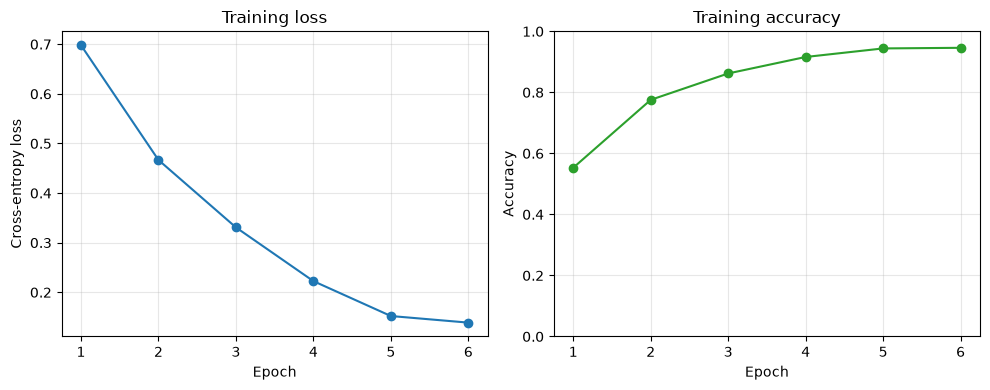

In [8]:
epoch_numbers = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epoch_numbers, history['loss'], marker='o')
axes[0].set(title='Training loss', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[0].grid(alpha=0.3)
axes[1].plot(epoch_numbers, history['accuracy'], marker='o', color='tab:green')
axes[1].set(title='Training accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1))
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Evaluate Held-Out Images

The model has not trained on these 400 test images. The confusion matrix records actual classes in rows and predicted classes in columns. A result above 50% is better than random guessing on this balanced two-class task, but it is not evidence of forensic validity.

Held-out test accuracy: 95.2%


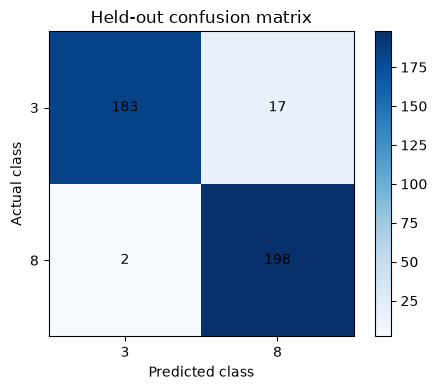

In [9]:
model.eval()
confusion = torch.zeros(2, 2, dtype=torch.int64)
all_images, all_labels, all_predictions, all_confidences = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        probabilities = torch.softmax(logits, dim=1).cpu()
        confidences, predictions = probabilities.max(dim=1)
        for actual, predicted in zip(labels, predictions):
            confusion[actual, predicted] += 1
        all_images.append(images)
        all_labels.append(labels)
        all_predictions.append(predictions)
        all_confidences.append(confidences)

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_predictions = torch.cat(all_predictions)
all_confidences = torch.cat(all_confidences)
test_accuracy = (all_predictions == all_labels).float().mean().item()
print(f'Held-out test accuracy: {test_accuracy:.1%}')
if test_accuracy <= 0.5:
    print('This run did not beat random chance. Re-run from the top and inspect the training curve.')

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion.numpy(), cmap='Blues')
for actual in range(2):
    for predicted in range(2):
        ax.text(predicted, actual, int(confusion[actual, predicted]), ha='center', va='center')
ax.set_xticks((0, 1), CLASS_NAMES)
ax.set_yticks((0, 1), CLASS_NAMES)
ax.set(xlabel='Predicted class', ylabel='Actual class', title='Held-out confusion matrix')
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## Step 9: Inspect Predictions and Confidence

Confidence is the larger of the model's two probabilities. It measures preference between the available labels—not whether the image is authentic, in distribution, or correctly classified. Notice whether any incorrect examples still receive high confidence.

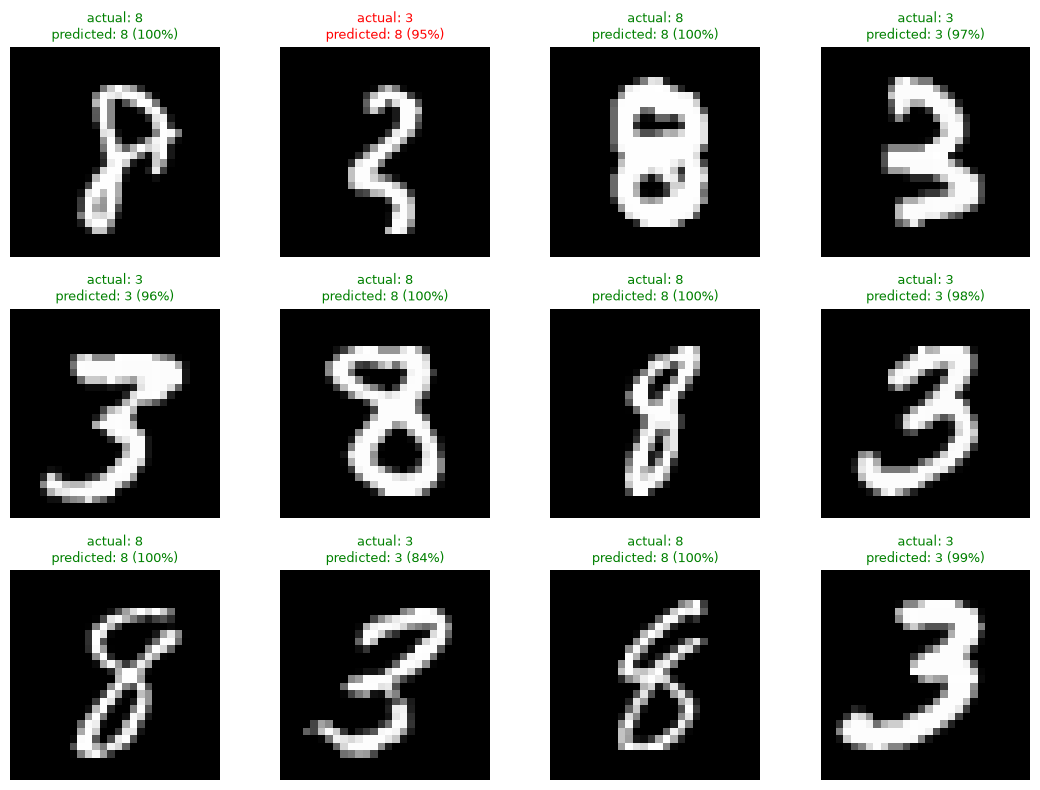

In [10]:
generator = torch.Generator().manual_seed(SEED)
chosen = torch.randperm(len(all_images), generator=generator)[:12]
fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for ax, index in zip(axes.flat, chosen):
    actual = all_labels[index].item()
    predicted = all_predictions[index].item()
    confidence = all_confidences[index].item()
    color = 'green' if actual == predicted else 'red'
    ax.imshow(image_for_display(all_images[index]), cmap='gray', vmin=0, vmax=1)
    ax.set_title(
        f'actual: {CLASS_NAMES[actual]}\npredicted: {CLASS_NAMES[predicted]} ({confidence:.0%})',
        color=color,
        fontsize=9,
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

## Interpretation

This tiny model learned from only 2,000 low-resolution images. Its result is meaningful as an implementation demonstration, but its mistakes reveal why a classification score must be bounded by the task and data. A photograph of a digit, unusual handwriting, rotation, crop, compression artifact, or non-digit image creates distribution shift. Because the head offers only two labels, it must still prefer `3` or `8` for an unrelated input.

In a forensic workflow, preserve the original artifact and record the model version, weights, preprocessing, class labels, input, and output. Corroborate any model-assisted lead with metadata, hashes, acquisition records, other evidence, validated procedures, and human review.

## Reflection

1. Why are there 49 patch tokens but 50 tokens entering the encoder?
2. Which line projects a 16-value patch vector into a 64-value embedding?
3. Why does this encoder not need the causal mask used by the tiny LLM?
4. What does the confusion matrix reveal that training accuracy does not?
5. Find an incorrect prediction. Was the model uncertain, or confidently wrong?
6. Why would a `3`-versus-`8` score fail to establish authenticity or provenance?
7. What would you record so another examiner could reproduce this classification?